# Binary Classification
Binary Classification is a type of supervised machine learning algorithm used to classify data into one of two categories. It predicts a binary outcome (e.g., true/false, yes/no, 0/1), where the result can either be positive or negative based on existing data features.

## Importing Dataset
The `ionosphere.csv` dataset contains radar signal data collected from the ionosphere. Each row represents a radar signal instance, with features derived from the received signals. The dataset is commonly used for binary classification tasks, where the goal is to distinguish between **good** signals (radar returns are those showing evidence of some type of structure in the ionosphere) and **bad** signals (their signals pass through the ionosphere and did not received by the radar).

In [2]:
# Import pandas API
import pandas as pd

# Read the input csv file
dataset = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data', header=None)

# Display 10 random samples from the dataset
dataset.sample(10).style.hide(axis="index")

0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34
1,0,0.988220,0.021870,0.931020,0.341000,0.839040,0.352220,0.747060,0.489060,0.735840,0.518790,0.550760,0.601790,0.431300,0.662370,0.318000,0.704430,0.283790,0.688730,0.075150,0.736960,0.063380,0.712840,-0.164890,0.697140,-0.165560,0.605100,-0.162090,0.558050,-0.347170,0.441950,-0.334830,0.374650,g
1,0,0.936580,0.351070,0.752540,0.656400,0.455710,0.885760,0.153230,0.957760,-0.217750,0.963010,-0.565350,0.833970,-0.787510,0.580450,-0.931040,0.260200,-0.936410,-0.064180,-0.870280,-0.409490,-0.650790,-0.674640,-0.367990,-0.849510,-0.045780,-0.912210,0.273300,-0.857620,0.548270,-0.696130,0.748280,-0.441730,g
1,0,1.000000,0.515150,0.454550,0.333330,0.060610,0.363640,-0.321040,0.730620,-0.454550,0.484850,-0.575760,0.000000,-0.575760,-0.121210,-0.333330,-0.484850,-0.090910,-0.848480,0.484850,-0.575760,0.575760,-0.424240,1.000000,-0.393940,0.729610,0.123310,0.969700,0.575760,0.242420,0.363640,0.090910,0.333330,g
1,0,1.000000,-0.055290,1.000000,-1.000000,0.500000,-0.111110,0.361110,-0.222220,1.000000,-0.257120,0.166670,-0.111110,1.000000,-0.346600,1.000000,-0.388530,1.000000,-0.428620,0.000000,-0.250000,1.000000,-0.503330,1.000000,-0.277780,1.000000,-0.570920,1.000000,-0.277780,1.000000,-0.631560,1.000000,-0.659350,b
1,0,0.852090,0.392520,0.388870,0.764320,0.088580,0.989030,-0.426250,0.887440,-0.762290,0.499800,-0.930920,0.107680,-0.859000,-0.310440,-0.660300,-0.552620,-0.192600,-0.860630,0.284440,-0.804960,0.646490,-0.352300,0.778140,-0.233240,0.716980,0.213430,0.378300,0.583100,0.196670,0.663150,-0.112150,0.649330,g
1,0,0.945980,-0.026850,-1.000000,0.261310,-0.363930,0.356390,0.692580,-0.634270,1.000000,-0.033530,-0.290200,-0.005500,-0.548520,0.154520,0.919210,-0.462700,1.000000,-0.504240,-0.297350,-0.314540,-0.738640,0.373610,0.838720,-0.467340,0.522080,-0.581300,1.000000,-0.613930,-0.096340,0.204770,-0.061170,0.419130,b
0,0,1.000000,-1.000000,-1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,1.000000,-1.000000,1.000000,b
1,0,0.811430,0.037140,0.851430,-0.001430,0.790000,0.007140,0.795710,-0.042860,0.875710,0.000000,0.855710,-0.067140,0.864290,0.002860,0.828570,-0.054290,0.810000,-0.118570,0.768570,-0.084290,0.842860,-0.050000,0.770000,-0.068570,0.815980,-0.086690,0.825710,-0.104290,0.814290,-0.050000,0.821430,-0.151430,g
0,0,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,-1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,b
1,0,0.454550,0.090910,0.636360,0.090910,0.272730,0.181820,0.636360,0.000000,0.363640,-0.090910,0.454550,-0.090910,0.486120,-0.013430,0.636360,-0.181820,0.454550,0.000000,0.363640,-0.090910,0.272730,0.181820,0.363640,-0.090910,0.344420,-0.017680,0.272730,0.000000,0.363640,0.000000,0.289850,-0.018320,g


## Handling Imbalanced Dataset
The class distribution of the standard **Ionosphere** binary classification dataset is imbalanced, with a majority **good (g)** class and a minority **bad (b)** class.
* **Good (g)** returns (majority class): Approximately 64% of instances.
* **Bad (b)** returns (minority class): Approximately 36% of total instances. 

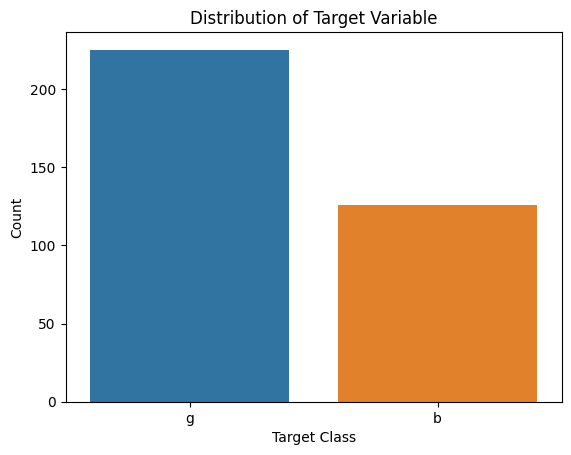

Good Sample Size,Bad Sample Size
225,126


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
sns.countplot(x=dataset.iloc[:, -1], hue=dataset.iloc[:, -1])
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

# Create a dataframe for the class sample sizes
dataset_samples_df = pd.DataFrame({
    'Good Sample Size': [dataset[dataset.iloc[:, -1] == 'g'].shape[0]],
    'Bad Sample Size': [dataset[dataset.iloc[:, -1] == 'b'].shape[0]]
})

# Display the distribution of the features for good and bad samples
dataset_samples_df.style.hide(axis="index")

**Oversampling** handles imbalanced data by increasing the number of minority class instances to match the majority class. Common methods include random oversampling (duplicating existing instances) and synthetic generation like `SMOTE` (Synthetic Minority Over-sampling Technique). Oversampling works well when the minority class contains unique or important information, but it can lead to overfitting and may not work well with high-dimensional data.

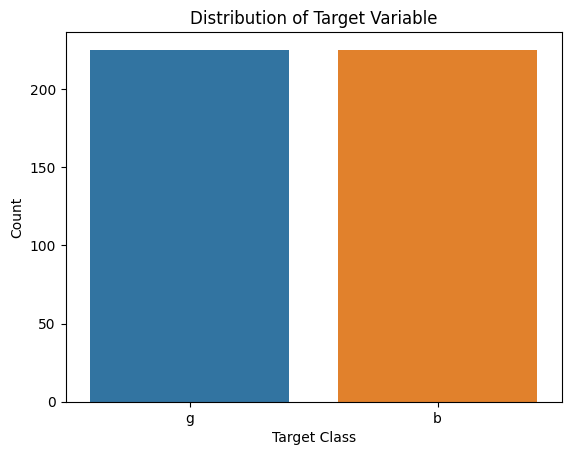

Good Sample Size,Bad Sample Size
225,225


In [17]:
from sklearn.utils import resample

# Apply oversampling to the minority class (bad samples) to balance the dataset
good_samples = dataset[dataset.iloc[:, -1] == 'g']
bad_samples = dataset[dataset.iloc[:, -1] == 'b']
oversampled_bad_samples = resample(bad_samples, replace=True, n_samples=good_samples.shape[0], random_state=42)

# Combine the oversampled bad samples with the good samples to create a balanced dataset
balanced_dataset = pd.concat([oversampled_bad_samples, good_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

# Plot the distribution of the target variable
sns.countplot(x=balanced_dataset.iloc[:, -1], hue=balanced_dataset.iloc[:, -1])
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

# Create a dataframe for the class sample sizes
balanced_dataset_samples_df = pd.DataFrame({
    'Good Sample Size': [balanced_dataset[balanced_dataset.iloc[:, -1] == 'g'].shape[0]],
    'Bad Sample Size': [balanced_dataset[balanced_dataset.iloc[:, -1] == 'b'].shape[0]]
})

# Display the distribution of the features for good and bad samples
balanced_dataset_samples_df.style.hide(axis="index")

## Assigning Features and Target Variables from the Dataset
**Features** also known as *predictors* are individual independent variables that act as input data in the classifier model.

**Targets** are the final output data trying to predict.

In [12]:
# Assigned data variables as features (from 3rd column to the 2nd last column)
features = balanced_dataset.drop(columns=[0, 1, balanced_dataset.columns[-1]])

# Display 10 random features dataframe
features.sample(10).style.hide(axis="index")

2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
0.454550,0.090910,0.636360,0.090910,0.272730,0.181820,0.636360,0.000000,0.363640,-0.090910,0.454550,-0.090910,0.486120,-0.013430,0.636360,-0.181820,0.454550,0.000000,0.363640,-0.090910,0.272730,0.181820,0.363640,-0.090910,0.344420,-0.017680,0.272730,0.000000,0.363640,0.000000,0.289850,-0.018320
1.000000,-0.006120,1.000000,-0.098340,1.000000,-0.076490,1.000000,-0.106050,1.000000,-0.110730,1.000000,-0.394890,1.000000,-0.156160,0.921240,-0.318840,0.864730,-0.345340,0.916930,-0.440720,0.960600,-0.468660,0.818740,-0.403720,0.826810,-0.422310,0.757840,-0.382310,0.804480,-0.405750,0.743540,-0.450390
0.906080,-0.016570,0.981220,-0.019890,0.956910,-0.036460,0.857460,0.001100,0.897240,-0.033150,0.890610,-0.014360,0.906080,-0.045300,0.913810,-0.008840,0.807730,-0.129280,0.887290,0.012150,0.921550,-0.023200,0.910500,-0.020990,0.891470,-0.077600,0.829830,-0.172380,0.960220,-0.037570,0.874030,-0.162430
0.960710,0.070880,1.000000,0.042960,1.000000,0.093130,0.901690,-0.051440,0.892630,0.025800,0.832500,-0.061420,0.875340,0.098310,0.765440,0.002800,0.752060,-0.052950,0.659610,-0.079050,0.641580,-0.059290,0.556770,-0.077050,0.580510,-0.022050,0.496640,-0.012510,0.513100,-0.000150,0.520990,-0.001820
0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,-1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,1.000000,1.000000,-1.000000
1.000000,-0.055290,1.000000,-1.000000,0.500000,-0.111110,0.361110,-0.222220,1.000000,-0.257120,0.166670,-0.111110,1.000000,-0.346600,1.000000,-0.388530,1.000000,-0.428620,0.000000,-0.250000,1.000000,-0.503330,1.000000,-0.277780,1.000000,-0.570920,1.000000,-0.277780,1.000000,-0.631560,1.000000,-0.659350
1.000000,0.083800,1.000000,0.173870,1.000000,-0.133080,0.981720,0.645200,1.000000,0.479040,1.000000,0.591130,1.000000,0.707580,1.000000,0.827770,1.000000,0.950990,1.000000,1.000000,0.980420,1.000000,0.916240,1.000000,0.838990,1.000000,0.748220,1.000000,0.643580,1.000000,0.524790,1.000000
0.881160,0.274750,0.721250,0.428810,0.615590,0.636620,0.388250,0.905020,0.098310,0.961280,-0.200970,0.892000,-0.357370,0.775000,-0.651140,0.622100,-0.787680,0.455350,-0.818560,0.190950,-0.839430,-0.080790,-0.783340,-0.263560,-0.675570,-0.455110,-0.547320,-0.608580,-0.305120,-0.667000,-0.193120,-0.755970
0.924360,0.369240,0.719760,0.684200,0.293030,0.940780,-0.111080,0.765270,-0.316050,0.924530,-0.666160,0.787660,-0.921450,0.423140,-0.943150,0.095850,-1.000000,0.031910,-0.664310,-0.662780,-0.460100,-0.781740,-0.134860,-0.880820,0.197650,-0.851370,0.489040,-0.702470,0.698860,-0.460480,0.760660,-0.131940


In [13]:
# Assigned target variable (last column)
targets = balanced_dataset.iloc[:, -1]

# Display 10 random targets dataframe
targets.sample(10)

145    b
346    g
80     b
268    g
206    b
334    g
435    b
124    g
225    b
113    g
Name: 34, dtype: str

## Preprocessing of Dataset
The **Standard Scaler** is a data preprocessing technique in machine learning that standardizes features by removing the mean and scaling the data to unit variance. This results in a transformed dataset with a mean of zero and a standard deviation of one for each feature.

The formula for the standard score (also known as the z-score) is described below:
$$
z=\frac{x-\mu}{  \sigma}
$$

Where
* $z$ is the scaled, or standardized, value (the z-score).
* $x$ is the original feature value.
* $\mu$ is the mean of the feature's training samples.
* $\sigma$ is the standard deviation of the feature's training samples. 

The primary purpose of the Standard Scaler is to ensure that features with different scales contribute equally to a model's objective function, preventing features with large variances from dominating those with smaller variances.

In [14]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform them
scaled_features = scaler.fit_transform(features)

## Visualizing Dataset Features Clusters

We can also apply **K-Means** clustering directly to the original features of the ionosphere dataset to see how the algorithm groups the data in the full feature space. Then, we can use the **Principal Component Analysis** (PCA) to reduce the dimensionality of the ionosphere dataset and visualize the clusters formed by the two classes (good and bad signals).

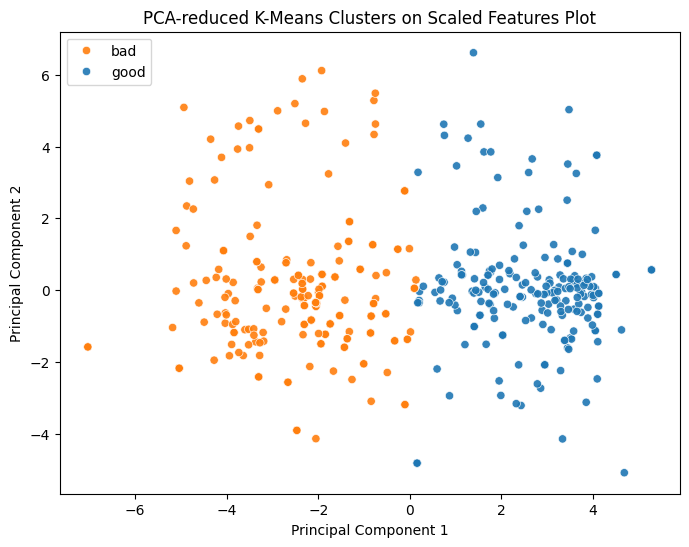

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Fit K-Means on original features
kmeans = KMeans(n_clusters = 2, random_state = 42,)
kmeans_labels = kmeans.fit(scaled_features).labels_

# Map K-Means labels to target classes for legend
mapped_kmeans_labels = ['good' if label == 0 else 'bad' for label in kmeans_labels]

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(scaled_features)

# Plot K-Means clusters in PCA-reduced space
plt.figure(figsize=(8, 6))
sns.scatterplot(x=features_2d[:, 0], y=features_2d[:, 1], hue = mapped_kmeans_labels, palette=['#ff7f0e', '#1f77b4'], alpha = 0.9)
plt.title('PCA-reduced K-Means Clusters on Scaled Features Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper left')
plt.show()

## Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to split the dataset into training and testing sets.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png" style="width:50%; height:auto; display: block; margin: 0 auto;">

In [18]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(scaled_features.astype("float32"), 
                                                    targets, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=targets)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape_df = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set'],
    'Samples': [balanced_dataset.shape[0], X_train.shape[0], X_test.shape[0]],
    'Features': [balanced_dataset.shape[1], X_train.shape[1], X_test.shape[1]],
    'Target Classes': [len(set(targets)), len(set(y_train)), len(set(y_test))]
})

# Display the dataset shape
dataset_shape_df.style.hide(axis="index")

Dataset,Samples,Features,Target Classes
Dataset,450,35,2
Training Set,360,32,2
Testing Set,90,32,2


## Train the Classifier Model
**K-Nearest Neighbors** (KNN) is a simple, supervised machine learning algorithm used for classification by identifying the nearest neighbors based on distance metrics (e.g., Euclidean, Manhattan) and selects the most common class (majority vote) for classification. It is a *lazy learner*, meaning it stores the entire training set rather than training a model, making inference slower on large datasets.

<img src="https://towardsdatascience.com/wp-content/uploads/2021/11/13SwcOCUyVdGauhHrHvOaLA.png" style="width:50%; height:auto; display: block; margin: 0 auto;">

The $k$ value in the k-NN algorithm *defines how many neighbors will be checked to determine the classification of a specific query point*. For example, if $k=1$, the instance will be assigned to the same class as its single nearest neighbor. The kNN algorithm takes $n d-dimensional$ training datapoints (our X matrix) that each have a corresponding y with discrete outputs (i.e. classes). In the above example, we have $n=8 d=2$ training examples. $4$ of them have **y=’red’** and the other $4$ have **y=’blue’**. The kNN algorithm uses this information to predict the class of the test point (orange) depending on the given $k$.

The kNN algorithm can be formally written as:
$$
f(\underline{x})=argmax_{c}(\left | {i:y_{i}=c, i\epsilon I}\right |)
$$

Our function $f$ takes in a vector $x$ (indicated by the underline) and classifies it as belonging to a class $c$. This is done by finding the most frequently occurring class in the nearest neighbours to $x$.

Where:
$$
I={i:\underline{x_{i}}\epsilon N(x;k)}
$$

$I$ represents the indices of the nearest neighbours to $x$. The function $N(x; k)$ finds the set of the nearest neighbours. Usually, the **Euclidean distance** is used as the distance metric. Then, it assigns the point to the class among its $k$ nearest neighbours (where $k$ is an integer). Euclidean distance equation finds that shortest possible distance using the equation as shown.
$$
d\left( p,q\right) = \sqrt {\sum _{i=1}^{n} \left( q_{i}-p_{i}\right)^2 }
$$

Where:
* $p,q$ = two points in Euclidean n-space
* $q_i, p_i$	=	Euclidean vectors, starting from the origin of the space (initial point)
* $n$	=	n-space

In [26]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
knn_clf = KNeighborsClassifier(metric='euclidean')

# Fit the KNN model on the training data
knn_clf.fit(X_train.astype("float32"), y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In technical terms, $k$ is a **hyperparameter in the KNN algorithm**. The user needs to define its best value, as it can’t learn the value from the input data. In the Scikit-learn KNN class, $k$ is specified as a hyperparameter using the **n_neighbors** argument. Scikit-learn provides a default value of $5$, but it is useless in most cases as the best $k$ value depends on many other factors. We will determine the best value of $k$ when training a KNN model machine learning use cases.

## Performance of the Classifier Model
Model performance is evaluated by measuring how accurately a machine learning model predicts categorical outcomes against ground-truth data, primarily using metrics like **accuracy**, **precision**, **recall**, and **F1-score**. These metrics are derived from a confusion matrix which compares predicted vs. actual classes to assess the model's ability to minimize false positives and false negatives. 

**Accuracy**: The overall proportion of correctly predicted observations (true positives + true negatives) out of the total, though it can be misleading on imbalanced datasets.

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

Where:
* **TP (True Positives)**: Correctly predicted positive instances.
* **TN (True Negatives)**: Correctly predicted negative instances.
* **FP (False Positives)**: Incorrectly predicted as positive.
* **FN (False Negatives)**: Incorrectly predicted as negative.

**Precision**: The ratio of true positive predictions to the total positive predictions made. High precision indicates a low false-positive rate.

$$
Precision = \frac{TP}{(TP + FP)}
$$

**Recall (Sensitivity)**: The ratio of true positive predictions to the total actual positive instances. High recall indicates the model catches most positive cases.
$$
Recall = \frac{TP}{(TP + FN)}
$$

**F1-Score**: The harmonic mean of precision and recall, providing a balanced measure of performance.
$$
F1_{score}=2 *\frac{Precesion * Recall}{Precesion + Recall}=\frac{2TP}{2TP+FP+FN}
$$

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Perform prediction on the test set
y_pred = knn_clf.predict(X_test.astype("float32"))

# Compute for classifier performance metrics such as accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='g')
recall = recall_score(y_test, y_pred, pos_label='g')
f1 = f1_score(y_test, y_pred, pos_label='g')

# Create a dataframe to hold the performance metrics
performance_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score (%)': [accuracy * 100.00, precision * 100.00, recall * 100.00, f1 * 100.00]
})

# Display the performance metrics
performance_metrics_df.style.hide(axis="index")

Metric,Score (%)
Accuracy,87.777778
Precision,84.000000
Recall,93.333333
F1 Score,88.421053


# Creating a Confusion Matrix
A confusion matrix is a NxN table used to evaluate the performance of a classification model by comparing actual target values against predicted values. It summarizes outcomes showing **true positives (TP)**, **true negatives (TN)**, **false positives (FP)**, and **false negatives (FN)** to identify where a model is accurate or "confused". 

<img src="https://i0.wp.com/glassboxmedicine.com/wp-content/uploads/2019/02/confusion-matrix.png?fit=1200%2C675&ssl=1" style="width:50%; height:auto; display: block; margin: 0 auto;">

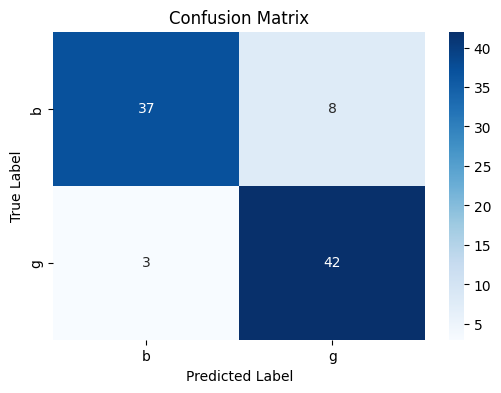

In [28]:
# Creating a confusion matrix to visualize the performance of the classifier using seaborn heatmap and scikit-learn's confusion_matrix function
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=knn_clf.classes_, yticklabels=knn_clf.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Choosing the Right Number of Neighbors (k) for the K-Nearest Neighbors (KNN) Algorithm
The choice of $k$ will largely depend on the input data as data with more outliers or noise will likely perform better with higher values of $k$. Overall, it is recommended to have an **odd number** for $k$ to **avoid ties in classification**, and **cross-validation** tactics can help you choose the optimal $k$ for your dataset.

### Grid Search Hyperparameter Optimization
To find the best $k$ value for KNN is to use Grid Search. Because $k$ is a hyperparameter, we can tune it using Grid Search. Here, we do the same thing as in the previous method. Here, we do not use an explicit for loop as Grid Search automatically does the looping for us! In addition to that, cross-validation also happens behind the scenes. We don’t need to do it manually. Here also, we train KNN 30 times with different k values ranging from 1 to 30!

In [29]:
from sklearn.model_selection import GridSearchCV

# Define the range of K values to search over
k_values = list(range(1, 31))

# Define the hyperparameter space for GridSearchCV
hyperparameter_space = {'n_neighbors':k_values}

# Initialize the KNN classifier
KNN = KNeighborsClassifier()

# Perform GridSearchCV to find the best K value based on accuracy
gs = GridSearchCV(KNN, param_grid=hyperparameter_space, scoring='accuracy', cv=5)

# Fit GridSearchCV on the scaled features and target variable
gs.fit(X_train.astype("float32"), y_train)

# Print the best K value and its corresponding mean cross-validation accuracy
print("Best value of K: ", gs.best_params_)
print("Mean CV accuracy of best K-value: ", gs.best_score_)

Best value of K:  {'n_neighbors': 2}
Mean CV accuracy of best K-value:  0.9388888888888889


### Finding the Best k Value Using NumPy argmax() Function
Using NumPy's ```argmax()``` to find the **best $k$ value** is a common step when tuning hyperparameters for algorithms like K-Nearest Neighbors (KNN). Since ```argmax()``` returns the index of the highest value in an array, you can use it to pinpoint which $k$ produced the highest accuracy during your testing. The general workflow involves creating a list of $k$ values, calculating an evaluation metric (like accuracy) for each, and then using ```argmax()``` to find the index of the maximum accuracy.

In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Define the range of K values to evaluate
k_values = list(range(1, 31)) # From 1 to 30

# Initialize an empty list to store the mean accuracy scores for each K value
acc_scores = []

# Loop through each K value, perform cross-validation, and store the mean accuracy 
# score for each K value
for k in k_values:
  KNN = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(KNN, X_train.astype("float32"), y_train,
                           scoring='accuracy', cv=5)
  acc_scores.append(np.mean(scores))

# Using NumPy argmax() to find the index of the best K value based on the 
# highest mean accuracy score
best_k_index = np.argmax(acc_scores)
best_k = k_values[best_k_index]

# Print the best K value and its corresponding mean accuracy score
print("Best k:", best_k)
print("Score:", acc_scores[best_k_index])

Best k: 2
Score: 0.9388888888888889


### Retraining the KNN Model Using the Best K Value
To retrain a K-Nearest Neighbors (KNN) model with the optimal $K$, create a new model instance setting ```n_neighbors = best_k``` and fit it using the complete training dataset. Since KNN relies on proximity, always scale your features first to prevent distance metrics from skewing toward larger-scale variables

In [32]:
# Initialize the KNN classifier
knn_best_k_clf = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')

# Fit the KNN model on the training data
knn_best_k_clf.fit(X_train.astype("float32"), y_train)

# Perform prediction on the test set
y_pred = knn_best_k_clf.predict(X_test.astype("float32"))

# Compute for classifier performance metrics such as accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='g')
recall = recall_score(y_test, y_pred, pos_label='g')
f1 = f1_score(y_test, y_pred, pos_label='g')

# Create a dataframe to hold the performance metrics
performance_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score (%)': [accuracy * 100.00, precision * 100.00, recall * 100.00, f1 * 100.00]
})

# Display the performance metrics
performance_metrics_df.style.hide(axis="index")

Metric,Score (%)
Accuracy,91.111111
Precision,89.361702
Recall,93.333333
F1 Score,91.304348


# Select Random Test Samples for Prediction
Selecting random test samples for prediction involves a process called simple random sampling. The goal is to ensure the sample is an unbiased, representative subset of the entire dataset.

In [33]:
# Generate a random number ranges from the test set for inference
import numpy as np
random_index = np.random.randint(0, len(X_test))

# Extract the corresponding test sample and its true label
X_test_sample = X_test[random_index:random_index+1]
y_test_sample = y_test.iloc[random_index]

# Perform inference on the test sample using the trained KNN model and get the predicted label
predicted_label = knn_best_k_clf.predict(X_test_sample.astype("float32"))[0]

# Create a list that hold the raw features, scaled features, true label, and predicted label
raw_features_str = pd.DataFrame(
    scaler.inverse_transform(X_test_sample.astype("float32"))
).to_csv(header=False, index=False).strip()

scaled_features_str = pd.DataFrame(
    X_test_sample.astype("float32")
).to_csv(header=False, index=False).strip()

inference_data = {
    'Inference Data': ['Raw Features', 'Scaled Features', 'True Label', 'Predicted Label'],
    'Value': [raw_features_str, scaled_features_str, y_test_sample, predicted_label]
}

# Create a dataframe that hold the raw and scaled input features arrange in one column and multiple rows for the true label and predicted label
inference_df = pd.DataFrame(inference_data)

# Display the raw input features (before scaling), the scaled input features, and the true label
inference_df.style.set_properties(**{'text-align': 'left'}).hide(axis="index")

Inference Data,Value
Raw Features,"0.94333005,0.38574,0.48263,0.64533997,0.21572,0.77514,-0.55941004,0.64899004,-0.73675,0.42047998,-0.76050997,3.7252903e-09,-0.62706006,-0.31079,-0.38390997,-0.62157005,-0.12797001,-0.69286996,0.49909002,-0.6362001,0.71481,-0.37660003,0.73857,-0.05484,0.60098,0.30383998,0.45521003,0.60512006,0.027419984,0.54479,-0.21572,0.50457"
Scaled Features,"0.7100773,0.72248584,-0.06963709,1.0940899,-0.5992721,1.2453558,-1.7840871,0.9443417,-1.9703844,0.62659866,-1.8601068,-0.1119999,-1.4325712,-0.766799,-1.300213,-1.1442496,-0.6679353,-1.1914597,0.29288056,-1.1805495,0.62231344,-0.5371796,0.60515684,5.6020348e-05,0.13136393,0.6884392,0.17143808,1.1974493,-0.47788098,0.9854773,-1.0694212,1.0102729"
True Label,g
Predicted Label,g


# Visualizing the Model Decision Boundary
Visualizing ensemble multiclass classification decision boundaries involves plotting the high-dimensional model's predictions over a 2D meshgrid using tools like scikit-learn's `DecisionBoundaryDisplay`. This technique divides the feature space into regions representing each class, defining where the model changes predictions to show smoother, non-linear boundaries. For multiclass, this is often a complex, multi-segmented surface. When data has more than tow (2) features, technique like `Principal Component Analysis` (PCA) or `feature selection` is needed to plot boundaries on a 2D plot.

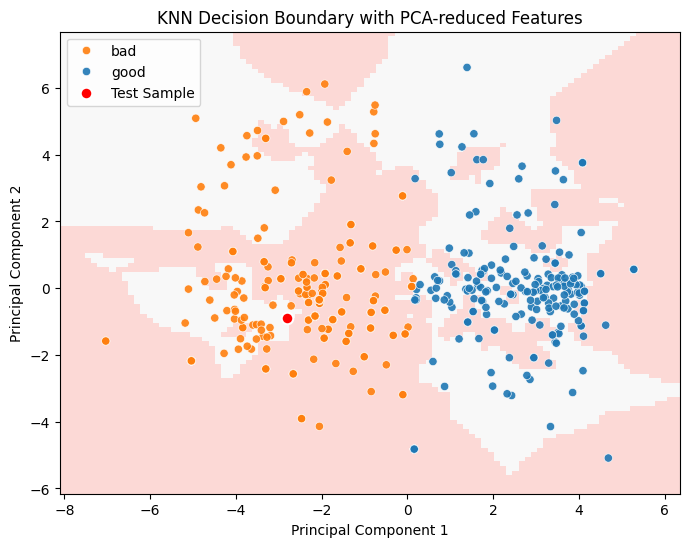

In [34]:
# Retrain the models using the selected features
knn_clf_2d = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_clf_2d.fit(features_2d.astype("float32"), targets)

# Transform the test set to 2D using the same PCA transformation
X_test_sample_2d = pca.transform(X_test_sample.astype("float32"))

# Combine the features_2d and the test sample features for visualization
features_2d_combined = np.vstack((features_2d, X_test_sample_2d))

# Import the DecisionBoundaryDisplay from scikit-learn
from sklearn.inspection import DecisionBoundaryDisplay

# Plot the decision boundary for KNN
figure, axes = plt.subplots(figsize=(8, 6))

# Compute the decision boundary using the DecisionBoundaryDisplay from scikit-learn
disp = DecisionBoundaryDisplay.from_estimator(knn_clf_2d, 
                                              features_2d,
                                              response_method='predict',
                                              plot_method='pcolormesh',
                                              shading='auto',
                                              cmap=plt.cm.Pastel1,
                                              alpha=0.5,
                                              ax=axes)

# Plot the original data points and the test sample in the PCA-reduced space
sns.scatterplot(x=features_2d[:, 0], y=features_2d[:, 1], hue = mapped_kmeans_labels, palette=['#ff7f0e', '#1f77b4'], alpha = 0.9)
sns.scatterplot(x=X_test_sample_2d[:, 0], y=X_test_sample_2d[:, 1], color='red', s=70, label='Test Sample', edgecolor='white', linewidth=1.5)
plt.title('KNN Decision Boundary with PCA-reduced Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper left')
plt.show()

# Port the Classifier Model to C Code
## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use ```pip install emlearn```

In [35]:
# Convert model using emlearn
import emlearn

# Convert the trained Decision Tree model to C++ code using emlearn
knn_clf_c_model = emlearn.convert(knn_best_k_clf, method='loadable', dtype='float', return_type='classifier')

# Generate and save the C code to a header file
knn_clf_c_code = knn_clf_c_model.save(file='KNNClassifier.h', name='KNNClassifier')

# Print the generated C code
print(knn_clf_c_code)

#include <eml_neighbors.h>
static const int16_t KNNClassifier_data[11520] = { 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, -1, 1, -2, 0, -2, 0, -1, 0, -1, -1, 0, -1, 0, -1, 0, -1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, -1, 1, -1, 0, -1, 0, -1, 0, -1, 0, -2, 0, -1, 0, -1, -1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2, 0, 1, -3, 1, 1, -2, 0, -2, -2, -2, -2, 1, 1, 1, 1, 1, -2, 1, 1, -1, 1, -1, 0, 1, 1, 1, -2, 1, -2, 2, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, -1, 1, -1, 0, 0, 1, 1, 1, 0, 0, 0, 1, -1, 1, 1, 1, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, -1, 1, -1, 1, -1, 1, -2, 0, -1, 0, -1, 0, -1, 0, 0, 0, 0, 0, 0